<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/15_langchain_middleware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain langchain-google-genai tavily-python langchain-core langchain_openai -q

In [2]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain.tools import tool, ToolRuntime
from langchain.messages import HumanMessage, SystemMessage, ToolMessage

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = userdata.get('GOOGLE_API_KEY')
os.environ['TAVILY_API_KEY'] = userdata.get('TAVILY_API_KEY')

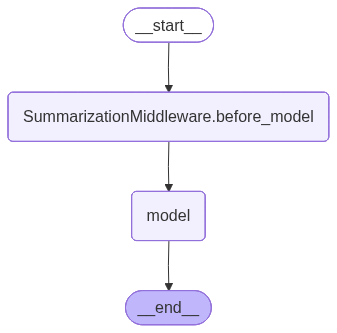

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware


model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model=model,
        trigger=("tokens", 100),
        keep=("messages", 2)
    )]
)

agent

In [6]:
from langchain.messages import HumanMessage, AIMessage
from pprint import pprint

response = agent.invoke(
    {"messages": [
        HumanMessage(content="What is the capital of the moon?"),
        AIMessage(content="The capital of the moon is Lunapolis."),
        HumanMessage(content="What is the weather in Lunapolis?"),
        AIMessage(content="Skies are clear, with a high of 120C and a low of -100C."),
        HumanMessage(content="How many cheese miners live in Lunapolis?"),
        AIMessage(content="There are 100,000 cheese miners living in Lunapolis."),
        HumanMessage(content="Do you think the cheese miners' union will strike?"),
        AIMessage(content="Yes, because they are unhappy with the new president."),
        HumanMessage(content="If you were Lunapolis' new president how would you respond to the cheese miners' union?"),
        ]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user is gathering information about the fictional lunar city of "Lunapolis," specifically its environment, population demographics (cheese miners), and the potential for labor unrest.\n\n## SUMMARY\n*   **Location:** Lunapolis is established as the capital of the moon.\n*   **Environment:** Extremely harsh conditions, with temperatures ranging from a high of 120°C to a low of -100°C; skies are clear.\n*   **Demographics:** The city has a population of 100,000 "cheese miners."\n*   **Current Inquiry:** The user is exploring the socio-political climate regarding the potential for a cheese miners\' union strike.\n\n## ARTIFACTS\nNone.\n\n## NEXT STEPS\n*   Analyze the likelihood of a cheese miners\' union strike in Lunapolis based on the established living conditions and population size.\n*   Provide a speculative assessment of labor stability in this fictional setting.', additiona

In [7]:
from tavily import TavilyClient

client = TavilyClient()

@tool
def search_internet(query:str):
    '''Searches given query in internet and validate the authenticity'''
    return client.search(query)

agent_with_tools = create_agent(
    model=model,
    tools=[search_internet],
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model=model,
        trigger=("tokens", 100),
        keep=("messages", 2)
    )]
)



response = agent_with_tools.invoke(
    {"messages": [
        SystemMessage("You are a helpful assistent who help in cross checking inputs provided by the user"),
        HumanMessage("Capital Moon is Melborne. It has beautiful sky scrappers and flashy buildings"),
        ]},
    {"configurable": {"thread_id": "2"}}
)

pprint(response)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user wants to cross-check the accuracy of their statement regarding the capital of Australia and the architectural characteristics of Melbourne.\n\n## SUMMARY\nThe user provided the following claims:\n1. "Capital Moon is Melborne." (Factually incorrect; the capital of Australia is Canberra).\n2. "It has beautiful sky scrappers and flashy buildings." (Melbourne is known for its modern architecture, skyscrapers, and urban development).\n\n## ARTIFACTS\nNone.\n\n## NEXT STEPS\nCorrect the user\'s misconception regarding the capital city of Australia while confirming the factual description of Melbourne\'s architecture.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='7d6ff06e-0419-40bd-890d-40412c6b659f'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_internet', 'arguments': '{"query": "capital of Melbourne"}'}

In [8]:
response = agent_with_tools.invoke(
    {"messages": [
        HumanMessage("Next olymbics is going to be conducted in capital of Moon"),
        ]},
    {"configurable": {"thread_id": "2"}}
)

pprint(response)

{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\nThe user is exploring facts about global capitals and events, currently transitioning from a discussion about Australian geography to a claim regarding the 2032 Olympics and a "capital of the Moon." The goal is to address these claims factually while maintaining the established context of the conversation.\n\n## SUMMARY\n*   **Geographic Clarification:** The conversation previously established that Melbourne is the capital of Victoria, while Canberra is the capital of Australia.\n*   **Current Claim:** The user has claimed the next Olympics will be held in the "capital of the Moon."\n*   **Context:** Previous discussion focused on correcting geographical misconceptions about Australia. The current input introduces a speculative/fictional claim that requires a factual pivot to the actual host of the upcoming Olympic Games.\n\n## ARTIFACTS\nNone.\n\n## NEXT STEPS\n*   Address the user